<a href="https://colab.research.google.com/github/MJ-SU/AI_demo_in_colab/blob/main/%E8%87%AA%E8%A8%82%E5%87%BD%E6%95%B8%E5%9C%96%E5%BD%A2%E5%BB%BA%E7%AB%8B(%E6%B4%9B%E5%80%AB%E8%8C%B2%E5%90%B8%E5%BC%95%E5%AD%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**洛倫茲吸引子（Lorenz Attractor）**
一個非線性動態系統的數學模型，最初由氣象學家愛德華·洛倫茲（Edward Lorenz）於1963年提出，用於描述大氣對流的行為。這個模型由一組微分方程組成，表現出混沌行為，即對初始條件極其敏感，微小的變化可能導致完全不同的結果。洛倫茲吸引子通常顯示出一個三維的蝴蝶型圖案，具有自相似的結構。

洛倫茲系統的微分方程為：

𝑑
𝑥 /
𝑑
𝑡
=
𝜎
(
𝑦
−
𝑥
)

𝑑
𝑦 /
𝑑
𝑡
=
𝑥
(
𝜌
−
𝑧
)
−
𝑦

𝑑
𝑧 /
𝑑
𝑡
=
𝑥
𝑦
−
𝛽
𝑧

這裡的
𝜎
σ,
𝜌
ρ, 和
𝛽
β 是系統的三個控制參數，分別影響系統的動態行為。

各參數的影響：

sigma (σ)：

這是“普朗特數”（Prandtl number），表示流體中粘性與熱擴散的比率。它影響 x 和 y 軸之間的交互速率。

增大 σ： 增加了 x 和 y 軸之間的相互作用，導致系統行為更為“劇烈”或快速，吸引子會變得更加複雜。


beta (β)：

這是系統中的一個對稱性參數，控制 z 軸的收斂速率，與系統的伸展和收縮有關。

增大 β： 通常會使吸引子變得更加“寬大”且有更多的擴展結構，吸引子看起來會變得更扁平。

rho (ρ)：

這個參數影響流體的對流強度，是洛倫茲模型中最關鍵的參數。

增大 ρ： 使系統從穩定狀態轉變為混沌狀態。較大的 ρ 值會導致吸引子的複雜性增強，表現為更多的翅膀結構，並且可能出現顯著的混沌行為。

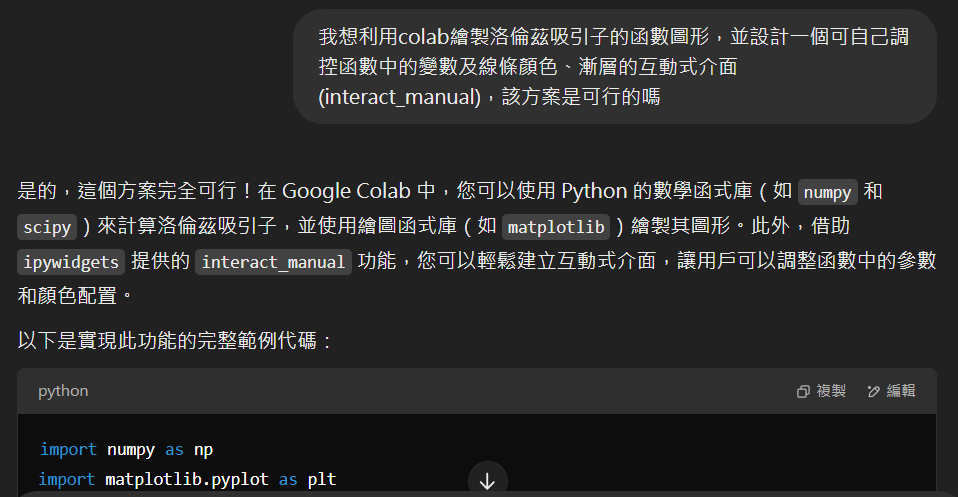

#導入所需的庫


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import ipywidgets as widgets
from ipywidgets import interact_manual
from ipywidgets import interact, widgets, Button, Layout, VBox, HBox

#函數定義

In [ ]:
# 定義洛倫茲吸引子的微分方程
def lorenz(t, state, sigma, beta, rho):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

#函數圖形繪製加上互動式介面設計

In [ ]:
# 定義洛倫茲吸引子的微分方程
def lorenz(t, state, sigma, beta, rho):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# 繪製洛倫茲吸引子的函數，支持顏色漸變
def plot_lorenz_gradient(sigma=10, beta=8/3, rho=28, t_max=50, dt=0.01, colormap='viridis', linewidth=1):
    # 初始條件
    initial_state = [1.0, 1.0, 1.0]

    # 時間範圍
    t_span = (0, t_max)
    t_eval = np.arange(0, t_max, dt)

    # 解微分方程
    sol = solve_ivp(lorenz, t_span, initial_state, args=(sigma, beta, rho), t_eval=t_eval, method='RK45')

    # 提取數據
    x, y, z = sol.y

    # 計算顏色對應的參數（使用時間序列 t_eval）
    t_normalized = (t_eval - t_eval.min()) / (t_eval.max() - t_eval.min())
    cmap = plt.get_cmap(colormap)
    colors = cmap(t_normalized)

    # 創建顏色漸變的線條
    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = Line3DCollection(segments, cmap=colormap, linewidth=linewidth)
    lc.set_array(t_normalized)

    # 繪圖
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(projection='3d')
    ax.add_collection3d(lc)
    ax.set_xlim([x.min(), x.max()])
    ax.set_ylim([y.min(), y.max()])
    ax.set_zlim([z.min(), z.max()])
    ax.set_title('Lorenz Attractor with Gradient', fontsize=14)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    plt.colorbar(lc, ax=ax, label='Time Gradient')
    plt.show()

# 使用 interact_manual 建立互動式介面
interact_manual(
    plot_lorenz_gradient,
    sigma=widgets.FloatSlider(value=10, min=0, max=20, step=0.5, description='Sigma'),
    beta=widgets.FloatSlider(value=8/3, min=0, max=5, step=0.1, description='Beta'),
    rho=widgets.FloatSlider(value=28, min=0, max=50, step=1, description='Rho'),
    t_max=widgets.IntSlider(value=50, min=10, max=100, step=10, description='T Max'),
    dt=widgets.FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001, description='DT'),
    colormap=widgets.Dropdown(options=plt.colormaps(), value='viridis', description='Colormap'),
    linewidth=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Linewidth'),
)

interactive(children=(FloatSlider(value=10.0, description='Sigma', max=20.0, step=0.5), FloatSlider(value=2.66…

<function __main__.plot_lorenz_gradient(sigma=10, beta=2.6666666666666665, rho=28, t_max=50, dt=0.01, colormap='viridis', linewidth=1)>

#互動介面改良

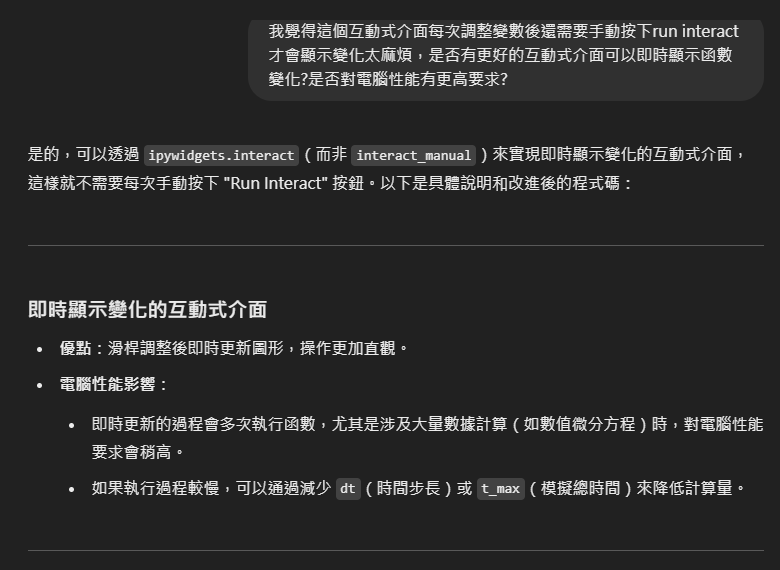

In [ ]:
# 繪製洛倫茲吸引子的函數，加上顏色漸變
def plot_lorenz_gradient(sigma=10, beta=8/3, rho=28, t_max=50, dt=0.01, colormap='viridis', linewidth=1):
    # 初始條件
    initial_state = [1.0, 1.0, 1.0]

    # 時間範圍
    t_span = (0, t_max)
    t_eval = np.arange(0, t_max, dt)

    # 解微分方程
    sol = solve_ivp(lorenz, t_span, initial_state, args=(sigma, beta, rho), t_eval=t_eval, method='RK45')

    # 提取數據
    x, y, z = sol.y

    # 計算顏色對應的參數（使用時間序列 t_eval）
    t_normalized = (t_eval - t_eval.min()) / (t_eval.max() - t_eval.min())
    cmap = plt.get_cmap(colormap)
    colors = cmap(t_normalized)

    # 創建顏色漸變的線條
    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = Line3DCollection(segments, cmap=colormap, linewidth=linewidth)
    lc.set_array(t_normalized)

    # 繪圖
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(projection='3d')
    ax.add_collection3d(lc)
    ax.set_xlim([x.min(), x.max()])
    ax.set_ylim([y.min(), y.max()])
    ax.set_zlim([z.min(), z.max()])
    ax.set_title('Lorenz Attractor with Gradient', fontsize=14)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    plt.colorbar(lc, ax=ax, label='Time Gradient')
    plt.show()

# 使用 interact_manual 建立互動式介面
interact(
    plot_lorenz_gradient,
    sigma=widgets.FloatSlider(value=10, min=0, max=20, step=0.5, description='Sigma (σ，控制x和y的交互速率)'),
    beta=widgets.FloatSlider(value=8/3, min=0, max=5, step=0.1, description='Beta (β，控制z的收斂速率)'),
    rho=widgets.FloatSlider(value=28, min=0, max=50, step=1, description='Rho (ρ，控制吸引子的形狀)'),
    t_max=widgets.IntSlider(value=50, min=10, max=100, step=10, description='T Max (模擬時間範圍)'),
    dt=widgets.FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001, description='DT (時間步長)'),
    colormap=widgets.Dropdown(options=plt.colormaps(), value='viridis', description='Colormap (顏色漸層)'),
    linewidth=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Linewidth (線條寬度)'),
)

interactive(children=(FloatSlider(value=10.0, description='Sigma (σ，控制x和y的交互速率)', max=20.0, step=0.5), FloatSl…

<function __main__.plot_lorenz_gradient(sigma=10, beta=2.6666666666666665, rho=28, t_max=50, dt=0.01, colormap='viridis', linewidth=1)>

#迭代

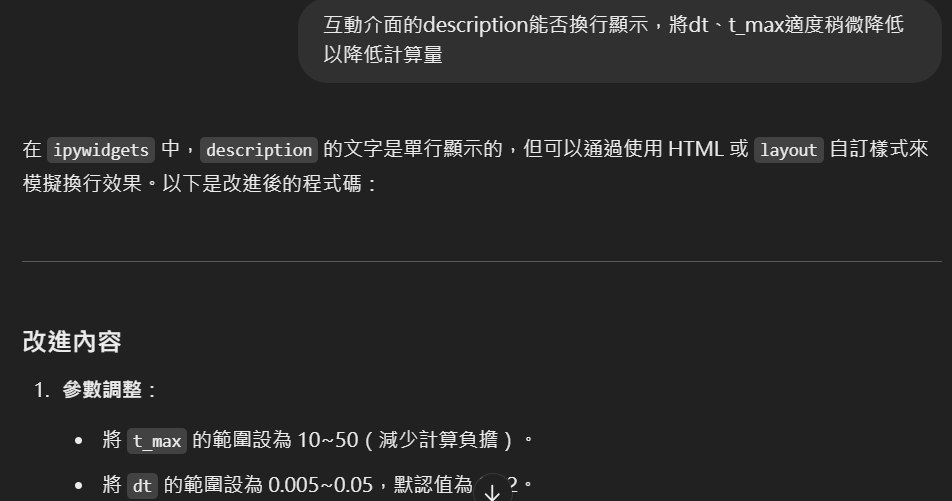

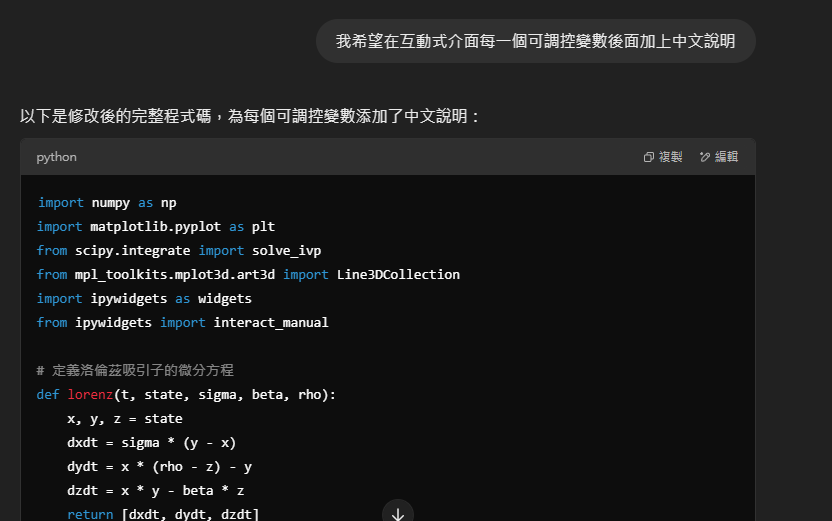

In [ ]:
# 繪製洛倫茲吸引子的函數，支持顏色漸變
def plot_lorenz_gradient(sigma=10, beta=8/3, rho=28, t_max=30, dt=0.02, colormap='viridis', linewidth=1):
    # 初始條件
    initial_state = [1.0, 1.0, 1.0]

    # 時間範圍
    t_span = (0, t_max)
    t_eval = np.arange(0, t_max, dt)

    # 解微分方程
    sol = solve_ivp(lorenz, t_span, initial_state, args=(sigma, beta, rho), t_eval=t_eval, method='RK45')

    # 提取數據
    x, y, z = sol.y

    # 計算顏色對應的參數（使用時間序列 t_eval）
    t_normalized = (t_eval - t_eval.min()) / (t_eval.max() - t_eval.min())
    cmap = plt.get_cmap(colormap)
    colors = cmap(t_normalized)

    # 創建顏色漸變的線條
    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = Line3DCollection(segments, cmap=colormap, linewidth=linewidth)
    lc.set_array(t_normalized)

    # 繪圖
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(projection='3d')
    ax.add_collection3d(lc)
    ax.set_xlim([x.min(), x.max()])
    ax.set_ylim([y.min(), y.max()])
    ax.set_zlim([z.min(), z.max()])
    ax.set_title('Lorenz Attractor with Gradient', fontsize=14)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    plt.colorbar(lc, ax=ax, label='Time Gradient')
    plt.show()

# 使用 interact 建立即時更新的互動式介面
print('洛倫茲吸引子相關變數調整區', )
interact(
    plot_lorenz_gradient,
    sigma=widgets.FloatSlider(
        value=10, min=0, max=20, step=0.5,
        description='Sigma (σ)\n控制x和y的交互速率',
        style={'description_width': '150px'},
        tooltip='σ (控制x和y的交互速率)'  # 改用tooltip
    ),
    beta=widgets.FloatSlider(
        value=8/3, min=0, max=5, step=0.1,
        description='Beta (β)\n控制z的收斂速率',
        style={'description_width': '150px'},
        tooltip='β (控制z的收斂速率)'  # 改用tooltip
    ),
    rho=widgets.FloatSlider(
        value=28, min=0, max=50, step=1,
        description='Rho (ρ)\n控制吸引子的形狀',
        style={'description_width': '150px'},
        tooltip='ρ (控制吸引子的形狀)'  # 改用tooltip
    ),
    t_max=widgets.IntSlider(
        value=30, min=10, max=50, step=5,
        description='T Max\n模擬時間範圍',
        style={'description_width': '150px'},
        tooltip='模擬時間範圍，越長耗時越多'  # 改用tooltip
    ),
    dt=widgets.FloatSlider(
        value=0.02, min=0.005, max=0.05, step=0.005,
        description='DT\n時間步長',
        style={'description_width': '150px'},
        tooltip='時間步長，越小計算越精細但耗時越多'  # 改用tooltip
    ),
    colormap=widgets.Dropdown(
        options=plt.colormaps(), value='viridis',
        description='Colormap\n顏色漸層',
        style={'description_width': '150px'},
        tooltip='選擇顏色漸層方案'  # 改用tooltip
    ),
    linewidth=widgets.FloatSlider(
        value=1, min=0.1, max=5, step=0.1,
        description='Linewidth\n線條寬度',
        style={'description_width': '150px'},
        tooltip='控制線條寬度'  # 改用tooltip
    ),
)
#減少計算負擔：
#降低 t_max 和 dt 的範圍降低計算量，確保流暢操作。
#備註中文說明
#當滑鼠懸停於description_tooltip時，顯示額外說明，提供更詳細的變數解釋。

洛倫茲吸引子相關變數調整區


interactive(children=(FloatSlider(value=10.0, description='Sigma (σ)\n控制x和y的交互速率', max=20.0, step=0.5, style=S…

<function __main__.plot_lorenz_gradient(sigma=10, beta=2.6666666666666665, rho=28, t_max=30, dt=0.02, colormap='viridis', linewidth=1)>